# Mobile Market Share

## Introdução

O presente dataset, elaborado pelos alunos **Leonardo José Bazana Lima, Pedro Paulo Fontelles Tooda e Vinicius Henrique Muniz**, propõe **responder questões relacionadas ao desenvolvimento mobile de software** no Mercado de 2026, apontando as principais tendências considerando o impacto na adoção Grandes Modelos de Linguagem (LLMs) e ferramentas de Inteligência Artificial para a **Engenharia de Aplicações Móveis**.  


### QUESTÃO 1

Pesquise em 2 fontes confiáveis (stackoverflow, Gartner, Microsoft, IBM, ...) **quais linguagens**(plataformas) de programação mobile tem sido mais usada pelo mercado nos anos de 2025, 2024 e 2023, no Brasil, nos EUA, na Europa e na Ásia.
Insira gráficos, um texto explicativo sobre o contexto da pesquisa e a URL da fonte.



#### Resposta 1

Consideramos como fonte o **stackoverflow developer survey** nos anos de 2023, 2024 e 2025 para uma **Análise Exploratória de Dados Robusta**, apontando tendências globais no mercado de desenvolvimento mobile.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
from google.colab import userdata
from pathlib import Path
import seaborn as sns

In [1]:


#baixando datasets
!kaggle datasets download -d stackoverflow/stack-overflow-2023-developers-survey #2023 survey
!kaggle datasets download -d ijnskjet/2024-stack-overflow-annual-developer-survey #2024
!kaggle datasets download -d edoardogalli/stack-overflow-annual-developer-survey-2025 #2025



Dataset URL: https://www.kaggle.com/datasets/stackoverflow/stack-overflow-2023-developers-survey
License(s): unknown
100% 20.5M/20.5M [00:01<00:00, 17.4MB/s]

Dataset URL: https://www.kaggle.com/datasets/ijnskjet/2024-stack-overflow-annual-developer-survey
License(s): EU ODP Legal Notice
100% 16.9M/16.9M [00:01<00:00, 16.3MB/s]

Dataset URL: https://www.kaggle.com/datasets/edoardogalli/stack-overflow-annual-developer-survey-2025
License(s): ODbL-1.0
100% 16.9M/16.9M [00:01<00:00, 15.5MB/s]



In [5]:
#criando uma lista de arquivos a serem extraídos
arquivos_kaggle_survey = [
  '2024-stack-overflow-annual-developer-survey.zip',
  'stack-overflow-2023-developers-survey.zip',
  'stack-overflow-annual-developer-survey-2025.zip']

#extraindo os arquivos .zip para uma pasta específica
pasta_destino_raiz = '/content/datasets_extraidos'

for arquivo in arquivos_kaggle_survey:

    nome_pasta = Path(arquivo).stem

    #criando o caminho final
    caminho_final_extracao = os.path.join(pasta_destino_raiz, nome_pasta)

    #criando a pasta caso nao existir
    os.makedirs(caminho_final_extracao, exist_ok=True)

    print(f"Extraindo {arquivo} para {caminho_final_extracao}...")

    with zipfile.ZipFile(arquivo, 'r') as zip_ref:
        #caminho da pasta específica criada como argumento
        zip_ref.extractall(caminho_final_extracao)

    print(f"Extração concluída. Removendo arquivo original...")

    os.remove(arquivo)
    print(f"Arquivo removido: {arquivo}\n")

print("Sucesso: datasets organizados, extraídos e dados compactados removidos!")

Extraindo 2024-stack-overflow-annual-developer-survey.zip para /content/datasets_extraidos/2024-stack-overflow-annual-developer-survey...
Extração concluída. Removendo arquivo original...
Arquivo removido: 2024-stack-overflow-annual-developer-survey.zip

Extraindo stack-overflow-2023-developers-survey.zip para /content/datasets_extraidos/stack-overflow-2023-developers-survey...
Extração concluída. Removendo arquivo original...
Arquivo removido: stack-overflow-2023-developers-survey.zip

Extraindo stack-overflow-annual-developer-survey-2025.zip para /content/datasets_extraidos/stack-overflow-annual-developer-survey-2025...
Extração concluída. Removendo arquivo original...
Arquivo removido: stack-overflow-annual-developer-survey-2025.zip

Sucesso: datasets organizados, extraídos e dados compactados removidos!


In [7]:
#lendo dados e criando dataframes
df_survey_2023 = pd.read_csv('/content/datasets_extraidos/stack-overflow-2023-developers-survey/survey_results_public.csv')
df_survey_2024 = pd.read_csv('/content/datasets_extraidos/2024-stack-overflow-annual-developer-survey/survey_results_public.csv')
df_survey_2025 = pd.read_csv('/content/datasets_extraidos/stack-overflow-annual-developer-survey-2025/survey_results_public.csv')

#criando copias

df_2023 = df_survey_2023.copy()
df_2024 = df_survey_2024.copy()
df_2025 = df_survey_2025.copy()

In [9]:
df_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89184 entries, 0 to 89183
Data columns (total 84 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ResponseId                           89184 non-null  int64  
 1   Q120                                 89184 non-null  object 
 2   MainBranch                           89184 non-null  object 
 3   Age                                  89184 non-null  object 
 4   Employment                           87898 non-null  object 
 5   RemoteWork                           73810 non-null  object 
 6   CodingActivities                     73764 non-null  object 
 7   EdLevel                              87973 non-null  object 
 8   LearnCode                            87663 non-null  object 
 9   LearnCodeOnline                      70084 non-null  object 
 10  LearnCodeCoursesCert                 37076 non-null  object 
 11  YearsCode                   

In [27]:
#criando um novo dataframe de 2023 apenas com as características relevantes
colunas_desejadas_2023 = ['Employment', 'YearsCode', 'DevType', 'OrgSize', 'Country', 'ProfessionalTech', 'Industry', 'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith', 'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith', 'ToolsTechHaveWorkedWith', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackSyncHaveWorkedWith', 'AIToolCurrently Using']

df_23 = df_2023[colunas_desejadas_2023]

df_23.head()

,Employment,YearsCode,DevType,OrgSize,Country,ProfessionalTech,Industry,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,ToolsTechHaveWorkedWith,OfficeStackAsyncHaveWorkedWith,OfficeStackSyncHaveWorkedWith,AIToolCurrently Using
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Employed, full-time",18,"Senior Executive (C-Suite, VP, etc.)",2 to 9 employees,United States of America,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",HTML/CSS;JavaScript;Python,Supabase,Amazon Web Services (AWS);Netlify;Vercel,Next.js;React;Remix;Vue.js,Docker;Kubernetes;npm;Pip;Vite;Webpack;Yarn,Asana;Basecamp;GitHub Discussions;Jira;Linear;...,Cisco Webex Teams;Discord;Google Chat;Google M...,Writing code;Committing and reviewing code
2,"Employed, full-time",27,"Developer, back-end","5,000 to 9,999 employees",United States of America,DevOps function;Microservices;Automated testin...,"Information Services, IT, Software Development...",Bash/Shell (all shells);Go,NaN,Amazon Web Services (AWS);Google Cloud;OpenSta...,NaN,Cargo;Docker;Kubernetes;Make;Nix,Markdown File;Stack Overflow for Teams,Microsoft Teams;Slack;Zoom,NaN
3,"Employed, full-time",12,"Developer, front-end",100 to 499 employees,United States of America,Automated testing;Continuous integration (CI) ...,NaN,Bash/Shell (all shells);HTML/CSS;JavaScript;PH...,PostgreSQL;Redis,Cloudflare;Heroku,Node.js;React;Ruby on Rails;Vue.js;WordPress,Homebrew;npm;Vite;Webpack;Yarn,Jira,Discord;Google Meet;Microsoft Teams;Slack;Zoom,NaN
4,"Employed, full-time;Independent contractor, fr...",6,"Developer, full-stack",20 to 99 employees,Philippines,Microservices;Automated testing;Observability ...,Other,HTML/CSS;JavaScript;TypeScript,BigQuery;Elasticsearch;MongoDB;PostgreSQL,Amazon Web Services (AWS);Firebase;Heroku;Netl...,Express;Gatsby;NestJS;Next.js;Node.js;React,Docker;npm;Webpack;Yarn,Confluence;Jira;Notion,Discord;Google Meet;Slack;Zoom,Learning about a codebase;Writing code;Documen...


In [28]:
#analisando todas as categorias presentes no dataset
contagem_devtype_23 = df_23['DevType'].value_counts()

print(contagem_devtype_23)


DevType
Developer, full-stack                            25735
Developer, back-end                              13745
Developer, front-end                              5071
Developer, desktop or enterprise applications     3904
Other (please specify):                           3080
Developer, mobile                                 2597
Engineering manager                               2033
Student                                           1996
Developer, embedded applications or devices       1845
Data scientist or machine learning specialist     1588
DevOps specialist                                 1387
Academic researcher                               1354
Research & Development role                       1353
Senior Executive (C-Suite, VP, etc.)              1332
Engineer, data                                    1248
Cloud infrastructure engineer                     1036
Developer, game or graphics                        866
Data or business analyst                           837
Sy

In [30]:
#filtrando apenas os desenvolvedores mobile
df_mobile_23 = df_23[df_23['DevType'].str.contains('Developer, mobile', na=False)].copy()

df_mobile_23.head()

,Employment,YearsCode,DevType,OrgSize,Country,ProfessionalTech,Industry,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,ToolsTechHaveWorkedWith,OfficeStackAsyncHaveWorkedWith,OfficeStackSyncHaveWorkedWith,AIToolCurrently Using
51,"Employed, full-time",4,"Developer, mobile",20 to 99 employees,Sri Lanka,Automated testing,Other,Swift,Firebase Realtime Database,NaN,NaN,NaN,NaN,Google Chat;Google Meet,Documenting code
54,"Employed, full-time",5,"Developer, mobile",I don’t know,Lebanon,NaN,NaN,Java;JavaScript;Kotlin;SQL;TypeScript,Firebase Realtime Database;Microsoft SQL Serve...,NaN,Node.js;React;Spring Boot,Dagger;Gradle;Maven (build tool),Confluence,Google Meet;Microsoft Teams;Slack;Zoom,NaN
176,"Employed, full-time",6,"Developer, mobile","Just me - I am a freelancer, sole proprietor, ...","Iran, Islamic Republic of...",DevOps function,Other,C;C++;Dart;Java;SQL,Microsoft SQL Server;MongoDB;MySQL;SQLite,Firebase;Google Cloud;VMware,NaN,CMake;Gradle,GitHub Discussions;Jira;Stack Overflow for Tea...,Discord;Google Meet;Skype;Slack;Telegram;Whatsapp,Project planning;Writing code;Debugging and ge...
177,"Employed, full-time",10,"Developer, mobile",20 to 99 employees,India,NaN,"Information Services, IT, Software Development...",Objective-C,SQLite,NaN,NaN,NaN,NaN,Microsoft Teams;Skype,NaN
179,"Employed, full-time;Student, full-time",5,"Developer, mobile",NaN,Lebanon,None of these,NaN,MATLAB;Swift,PostgreSQL,Digital Ocean;Google Cloud;Heroku;Microsoft Az...,NaN,Docker;Homebrew;LLVM's Clang,NaN,Google Meet;Microsoft Teams;Whatsapp;Zoom,NaN


--- Distribuição Numérica ---
Continent
Europe       1108
Asia          715
America       607
Africa        110
Oceania        56
not found       1
Name: count, dtype: int64


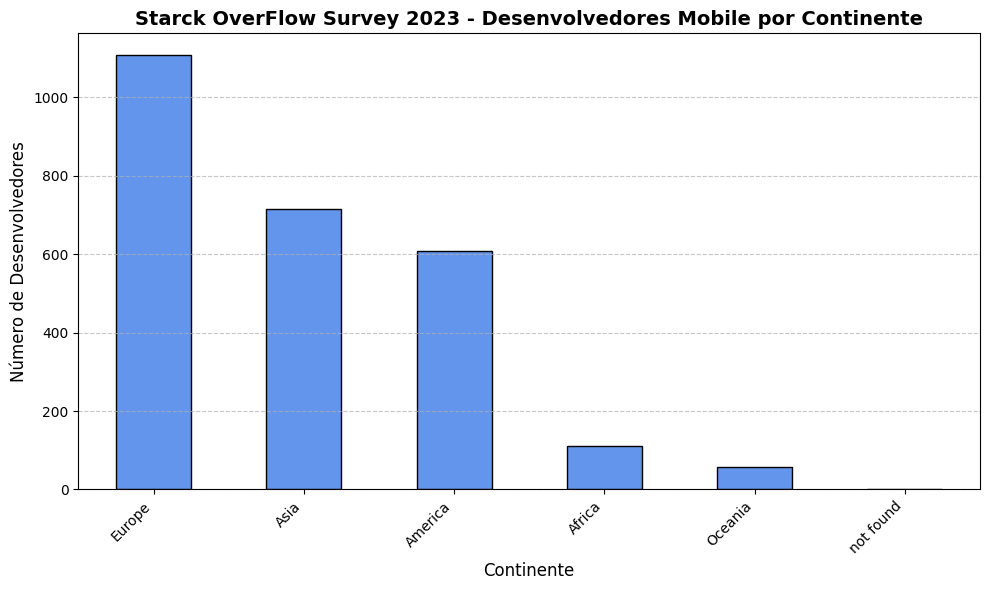

In [36]:
#distribuição por continente desses desenvolvedores em 2023
import country_converter as coco

#utilizando a biblioteca para converter os países em continentes
df_mobile_23['Continent'] = coco.convert(
    names=df_mobile_23['Country'].tolist(), to='continent'
)

#contando desenvolovedores por continente
distribuicao_continentes = df_mobile_23['Continent'].value_counts()

print('--- Distribuição Numérica ---')
print(distribuicao_continentes)

#criando gráfico de barras para visualizar a distribuição
plt.figure(figsize=(10, 6))
distribuicao_continentes.plot(
    kind='bar', color='cornflowerblue', edgecolor='black'
)

plt.title(
    'Starck OverFlow Survey 2023 - Desenvolvedores Mobile por Continente',
    fontsize=14,
    weight='bold',
)
plt.xlabel('Continente', fontsize=12)
plt.ylabel('Número de Desenvolvedores', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

#exibindo
plt.show()


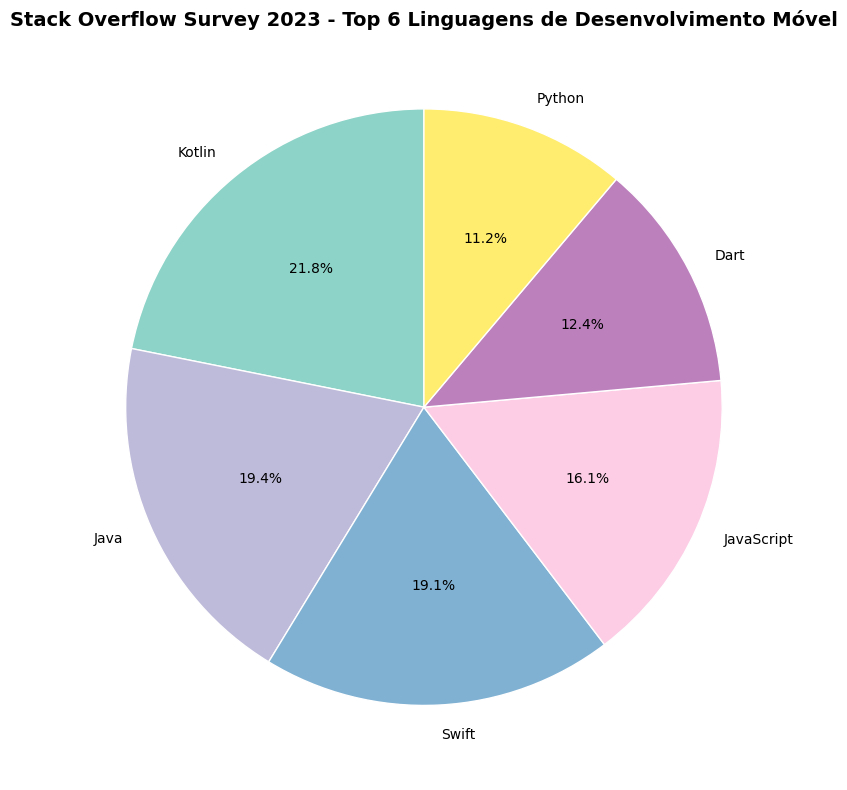

In [37]:
#analisando a distribuição das linguagens móveis em 2023
#separando as linguagens na mesma linha e contando a frequência
languages = (
    df_mobile_23['LanguageHaveWorkedWith']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
)

#selecionando apenas as 6 linguagens mais utilizadas
top_languages = languages.value_counts().head(6)

#criando o gráfico
plt.figure(figsize=(8, 8))
top_languages.plot.pie(
    autopct='%1.1f%%',  #porcentagem de cada fatia
    startangle=90,
    cmap='Set3',  #paleta de cores
    wedgeprops={'edgecolor': 'white'}  #linhas brancas
)

plt.title(
    'Stack Overflow Survey 2023 - Top 6 Linguagens de Desenvolvimento Móvel',
    fontsize=14,
    weight='bold',
)
plt.ylabel('')  #remove o rótulo
plt.tight_layout()

#exibre o gráfico de pizza
plt.show()

/tmp/ipykernel_2008/3163399351.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, 'Count'))
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/p

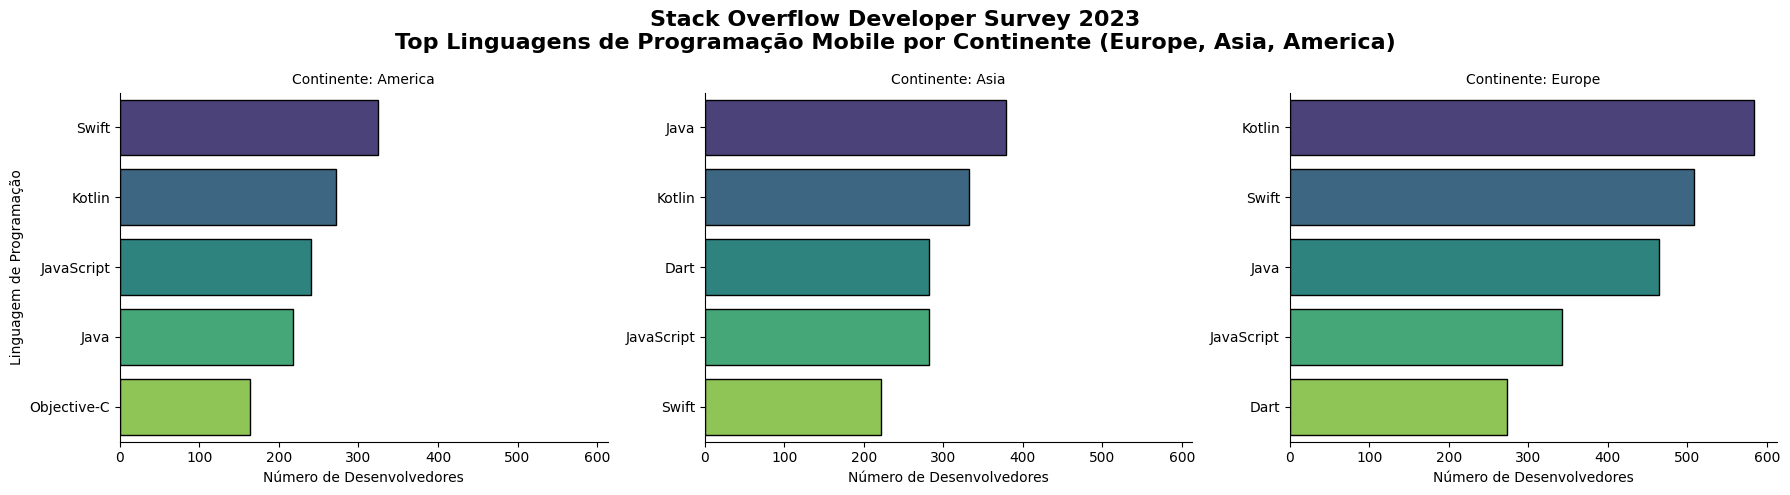

In [41]:
if 'Continent' not in df_mobile_23.columns:
  df_mobile_23['Continent'] = coco.convert(
      names=df_mobile_23['Country'].tolist(), to='continent'
  )

#filtrando apenas os continentes desejados Europe, Asia e America
continentes_desejados = ['Europe', 'Asia', 'America']
df_filtrado = df_mobile_23[
    df_mobile_23['Continent'].isin(continentes_desejados)
].copy()

#tratar linguagens separadas por ';'
df_explodido = (
    df_filtrado.assign(
        Language=df_filtrado['LanguageHaveWorkedWith'].str.split(';')
    )
    .explode('Language')
    .dropna(subset=['Language'])
)

#limpar espaços em branco extras
df_explodido['Language'] = df_explodido['Language'].str.strip()

#agrupar por Continente e Linguagem, contando a frequência
tabela_frequencia = (
    df_explodido.groupby(['Continent', 'Language'])
    .size()
    .reset_index(name='Count')
)

#5 linguagens mais usadas para cada continente
top_por_continente = (
    tabela_frequencia.groupby('Continent')
    .apply(lambda x: x.nlargest(5, 'Count'))
    .reset_index(drop=True)
)

#visualizacao (graf de barras separado por continente)
g = sns.FacetGrid(
    top_por_continente,
    col='Continent',
    sharey=False,
    height=5,
    aspect=1.2,
)
g.map_dataframe(
    sns.barplot,
    x='Count',
    y='Language',
    palette='viridis',
    edgecolor='black',
)


g.set_axis_labels('Número de Desenvolvedores', 'Linguagem de Programação')
g.set_titles(col_template='Continente: {col_name}')
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle(
    'Stack Overflow Developer Survey 2023\nTop Linguagens de Programação Mobile por Continente (Europe, Asia, America)',
    fontsize=16,
    weight='bold',
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2008/3901331851.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, 'Count'))
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/p

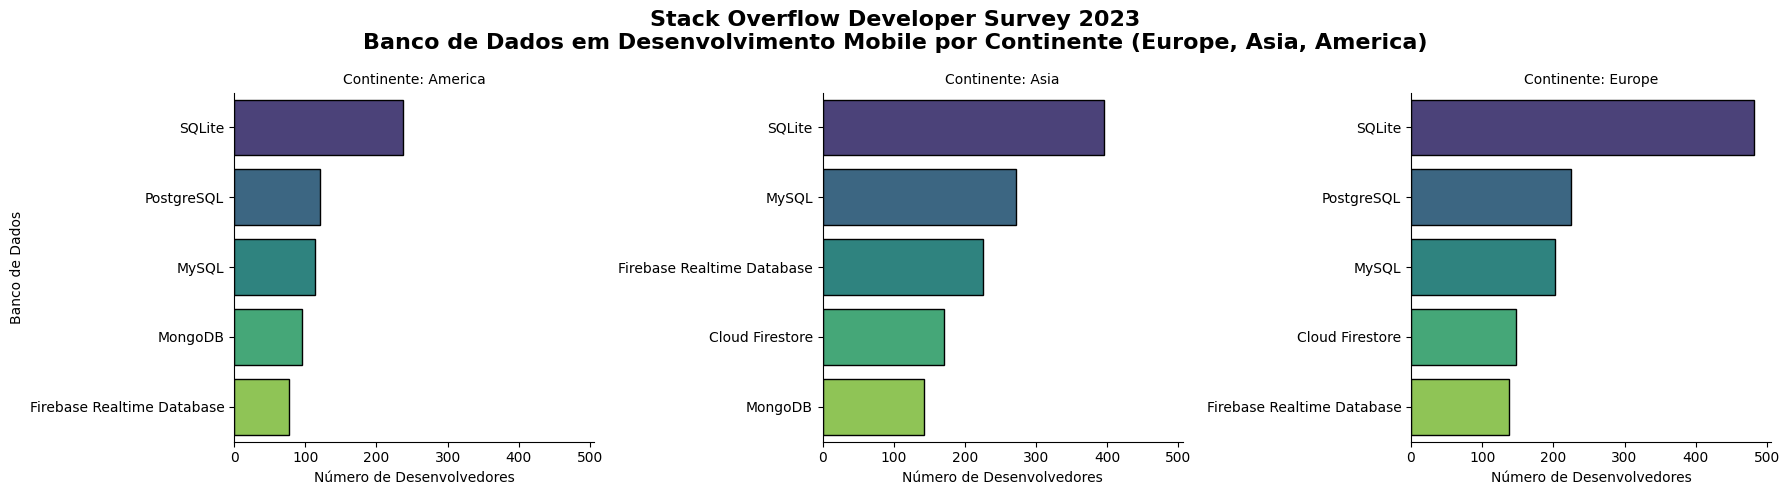

In [43]:
if 'Continent' not in df_mobile_23.columns:
  df_mobile_23['Continent'] = coco.convert(
      names=df_mobile_23['Country'].tolist(), to='continent'
  )

#filtrando apenas os continentes desejados Europe, Asia e America
continentes_desejados = ['Europe', 'Asia', 'America']
df_filtrado = df_mobile_23[
    df_mobile_23['Continent'].isin(continentes_desejados)
].copy()

#tratar linguagens separadas por ';'
df_explodido = (
    df_filtrado.assign(
        Language=df_filtrado['DatabaseHaveWorkedWith'].str.split(';')
    )
    .explode('Language')
    .dropna(subset=['Language'])
)

#limpar espaços em branco extras
df_explodido['Language'] = df_explodido['Language'].str.strip()

#agrupar por Continente e Linguagem, contando a frequência
tabela_frequencia = (
    df_explodido.groupby(['Continent', 'Language'])
    .size()
    .reset_index(name='Count')
)

#5 linguagens mais usadas para cada continente
top_por_continente = (
    tabela_frequencia.groupby('Continent')
    .apply(lambda x: x.nlargest(5, 'Count'))
    .reset_index(drop=True)
)

#visualizacao (graf de barras separado por continente)
g = sns.FacetGrid(
    top_por_continente,
    col='Continent',
    sharey=False,
    height=5,
    aspect=1.2,
)
g.map_dataframe(
    sns.barplot,
    x='Count',
    y='Language',
    palette='viridis',
    edgecolor='black',
)


g.set_axis_labels('Número de Desenvolvedores', 'Banco de Dados')
g.set_titles(col_template='Continente: {col_name}')
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle(
    'Stack Overflow Developer Survey 2023\nBanco de Dados em Desenvolvimento Mobile por Continente (Europe, Asia, America)',
    fontsize=16,
    weight='bold',
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2008/627584278.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, 'Count'))
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/py

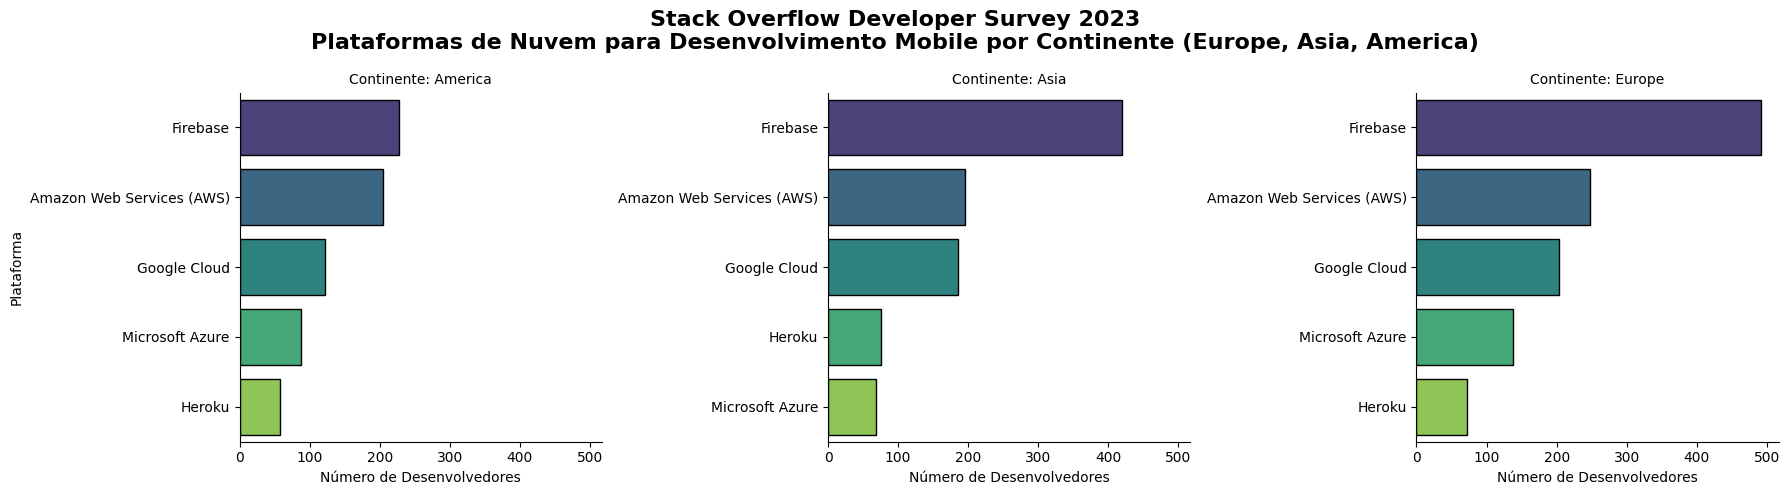

In [47]:
if 'Continent' not in df_mobile_23.columns:
  df_mobile_23['Continent'] = coco.convert(
      names=df_mobile_23['Country'].tolist(), to='continent'
  )

#filtrando apenas os continentes desejados Europe, Asia e America
continentes_desejados = ['Europe', 'Asia', 'America']
df_filtrado = df_mobile_23[
    df_mobile_23['Continent'].isin(continentes_desejados)
].copy()

#tratar linguagens separadas por ';'
df_explodido = (
    df_filtrado.assign(
        Language=df_filtrado['PlatformHaveWorkedWith'].str.split(';')
    )
    .explode('Language')
    .dropna(subset=['Language'])
)

#limpar espaços em branco extras
df_explodido['Language'] = df_explodido['Language'].str.strip()

#agrupar por Continente e Linguagem, contando a frequência
tabela_frequencia = (
    df_explodido.groupby(['Continent', 'Language'])
    .size()
    .reset_index(name='Count')
)

#5 linguagens mais usadas para cada continente
top_por_continente = (
    tabela_frequencia.groupby('Continent')
    .apply(lambda x: x.nlargest(5, 'Count'))
    .reset_index(drop=True)
)

#visualizacao (graf de barras separado por continente)
g = sns.FacetGrid(
    top_por_continente,
    col='Continent',
    sharey=False,
    height=5,
    aspect=1.2,
)
g.map_dataframe(
    sns.barplot,
    x='Count',
    y='Language',
    palette='viridis',
    edgecolor='black',
)


g.set_axis_labels('Número de Desenvolvedores', 'Plataforma')
g.set_titles(col_template='Continente: {col_name}')
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle(
    'Stack Overflow Developer Survey 2023\nPlataformas de Nuvem para Desenvolvimento Mobile por Continente (Europe, Asia, America)',
    fontsize=16,
    weight='bold',
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2008/1563822701.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(5, 'Count'))
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/p

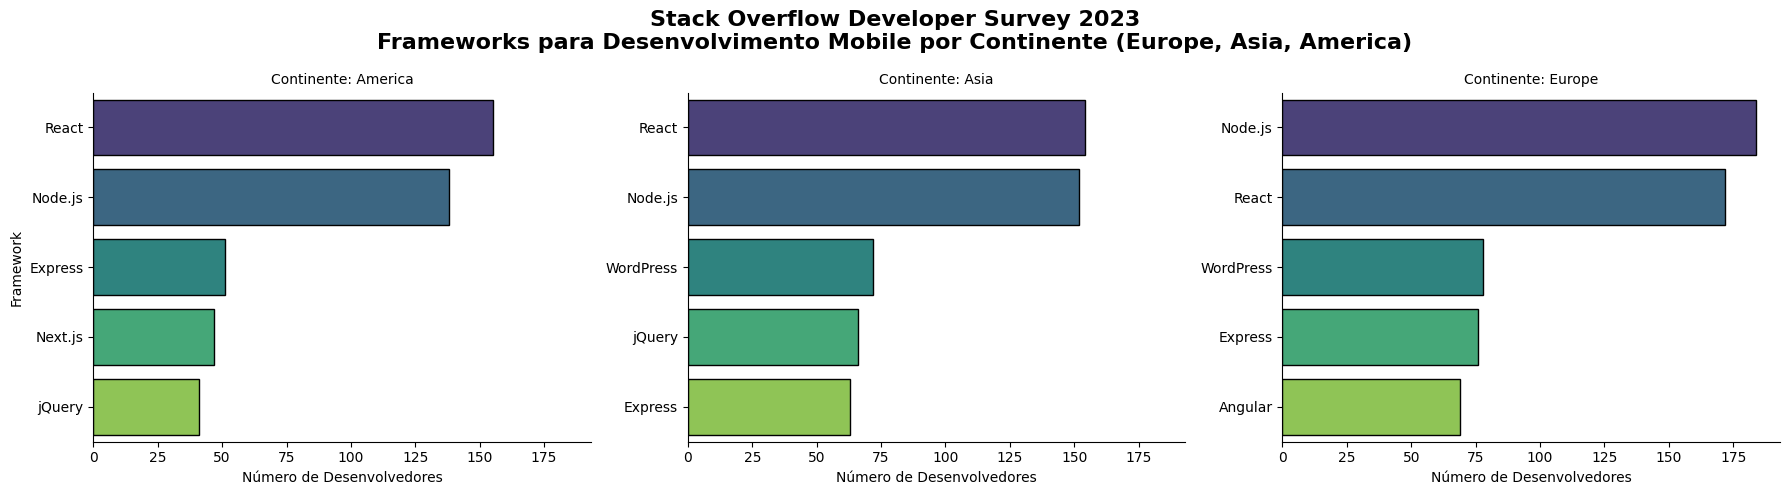

In [49]:
if 'Continent' not in df_mobile_23.columns:
  df_mobile_23['Continent'] = coco.convert(
      names=df_mobile_23['Country'].tolist(), to='continent'
  )

#filtrando apenas os continentes desejados Europe, Asia e America
continentes_desejados = ['Europe', 'Asia', 'America']
df_filtrado = df_mobile_23[
    df_mobile_23['Continent'].isin(continentes_desejados)
].copy()

#tratar linguagens separadas por ';'
df_explodido = (
    df_filtrado.assign(
        Language=df_filtrado['WebframeHaveWorkedWith'].str.split(';')
    )
    .explode('Language')
    .dropna(subset=['Language'])
)

#limpar espaços em branco extras
df_explodido['Language'] = df_explodido['Language'].str.strip()

#agrupar por Continente e Linguagem, contando a frequência
tabela_frequencia = (
    df_explodido.groupby(['Continent', 'Language'])
    .size()
    .reset_index(name='Count')
)

#5 linguagens mais usadas para cada continente
top_por_continente = (
    tabela_frequencia.groupby('Continent')
    .apply(lambda x: x.nlargest(5, 'Count'))
    .reset_index(drop=True)
)

#visualizacao (graf de barras separado por continente)
g = sns.FacetGrid(
    top_por_continente,
    col='Continent',
    sharey=False,
    height=5,
    aspect=1.2,
)
g.map_dataframe(
    sns.barplot,
    x='Count',
    y='Language',
    palette='viridis',
    edgecolor='black',
)


g.set_axis_labels('Número de Desenvolvedores', 'Framework')
g.set_titles(col_template='Continente: {col_name}')
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle(
    'Stack Overflow Developer Survey 2023\nFrameworks para Desenvolvimento Mobile por Continente (Europe, Asia, America)',
    fontsize=16,
    weight='bold',
)

plt.tight_layout()
plt.show()

In [ ]:
print(df_2024)

In [15]:
df_2025.describe()

,ResponseId,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,ConvertedCompYearly,JobSat
count,49123.000000,42844.000000,43000.000000,35943.000000,35943.000000,35943.000000,35943.000000,35943.000000,35943.000000,35943.000000,...,26241.000000,26241.000000,26241.000000,26241.000000,26241.000000,26241.000000,26241.000000,26241.000000,2.392800e+04,26643.000000
mean,24562.000000,13.370810,16.575256,7.867763,4.104415,4.110341,5.678574,4.119383,5.225830,6.477562,...,5.718456,4.562097,4.791014,5.198925,5.676232,4.984033,7.100149,10.079341,1.017916e+05,7.202042
std,14180.732974,10.801917,11.789269,2.397243,2.276154,2.329539,2.397899,2.437938,2.801354,2.331433,...,2.628090,3.070817,2.643243,2.563386,2.311023,2.490411,2.469361,1.941629,4.619345e+05,1.997234
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,0.000000
25%,12281.500000,5.000000,8.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,...,3.000000,1.000000,3.000000,3.000000,4.000000,3.000000,6.000000,10.000000,3.817100e+04,6.000000
50%,24562.000000,10.000000,14.000000,9.000000,4.000000,4.000000,6.000000,4.000000,5.000000,7.000000,...,6.000000,4.000000,5.000000,5.000000,6.000000,5.000000,8.000000,10.000000,7.538350e+04,8.000000
75%,36842.500000,20.000000,24.000000,9.000000,6.000000,6.000000,8.000000,6.000000,8.000000,8.000000,...,8.000000,7.000000,7.000000,7.000000,7.000000,7.000000,9.000000,10.000000,1.206302e+05,8.000000
max,49123.000000,100.000000,100.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,5.000000e+07,10.000000


2) Pesquise em 2 fontes confiáveis qual a participação de mercado (marketshare) dos dispositivos Android e iOS nos anos de 2025 e 2024, no Brasil, nos EUA, na Europa e na Ásia.
Insira gráficos, um texto explicativo sobre o contexto da pesquisa e a URL da fonte.



3) Cite 2 exemplos comerciais de alto grau de inovação tecnológica concebidos sobre o paradigma de computação móvel.
Insira gráficos, um texto explicativo sobre o contexto da pesquisa e a URL da fonte.



4) Cite 5 aplicações mobile comercializadas via play store ou apple store de maior faturamento no ano de 2024 e 2025. Descreva o nome, faturamento, quantidade de downloads e fontes.



5) Cite outras 10 aplicações mobile comercializadas via play store ou apple store de maior faturamento no ano de 2024 e 2025 que não sejam no segmento de jogos. Descreva o nome, faturamento, quantidade de downloads e fontes.

6) Cite 5 aplicações mobile comercializadas via play store ou apple store de maior faturamento no ano de 2024 e 2025 no segmento do projeto que você quer desenvolver ao término da disciplina. . Descreva o nome, faturamento, quantidade de downloads e fontes.

7) Qual o aparelho celular de maior poder de processamento comercializado no mundo e o seu preço?

8) Qual o aparelho celular de maior memória RAM comercializado no mundo e o seu preço?